In [28]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from traj_gen_utils import MINCO_S3NU

from traj_gen_utils import load_voxel_grid
import pyvista as pv
pv.set_jupyter_backend('html')

# load voxel grid environment
path = "traj_gen_utils/data/forest.txt"
vg = load_voxel_grid(path, padding=0)
vg.plot_pyvista()
grid3D = vg.grid

from traj_gen_utils import astar_3d, visualize

start = (1, 5, 10)
goal = (90, 90, 10)
start_grid_idx = vg.info.to_index(start)
goal_grid_idx = vg.info.to_index(goal)

path_indices = astar_3d(grid3D, start_grid_idx, goal_grid_idx, connectivity=18)
visualize(vg, path_indices)

import pydecomp as pdc
from traj_gen_utils import visualize_voxelgrid_with_path
from traj_gen_utils import reduce_turns_by_los

# prune path to only keep straight line segments
path = reduce_turns_by_los(np.array(path_indices), grid3D)

origin    = np.asarray(vg.info.origin, dtype=np.float64)
occ_idx   = np.argwhere(vg.grid == 1)
obs_np    = (occ_idx + 0.5).astype(np.float64) + origin
path_np   = (np.asarray(path, np.float64) + 0.5) + origin 
box_np    = np.array([[5.0, 5.0, 5.0]], dtype=np.float64)

A_list, b_list = pdc.convex_decomposition_3D(obs_np, path_np, box_np)
# (A_list, b_list) is a list of half-space representations of convex polytopes

visualize_voxelgrid_with_path(vg, path_indices, A_list=A_list, b_list=b_list)


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

[viz] surf points/cells: 128248 128848
[viz] surf bounds: BoundsTuple(x_min =   0.0,
            x_max = 100.0,
            y_min =   0.0,
            y_max = 100.0,
            z_min =   0.0,
            z_max =  40.0)
[viz] centers min/max: [ 1.5  5.5 10.5] [91.5 90.5 10.5]
[viz] segments: 5


EmbeddableWidget(value='<iframe srcdoc="<!DOCTYPE html>\n<html>\n  <head>\n    <meta http-equiv=&quot;Content-…

## Spatio-Temporal Planner

---

### 0) Overview

&nbsp;&nbsp;&nbsp;&nbsp;This note summarizes the mathematical background used in the **Spatio-Temporal Planner**.  
&nbsp;&nbsp;&nbsp;&nbsp;The sections and their subtopics are:

1. **Safe Flight Corridor & Polytope Constraints**
   - **1.1) H-Representation of a Convex Polytope**
   - **1.2) Diffeomorphisms and V-Representation**
     - **1.2.1) What is a Diffeomorphism?**
     - **1.2.2) Why Map H-Representation to V-Representation?**
   - **1.3) Procedure to Eliminate Polytope Constraints**
     - **1.3.1) Step 1 – Barycentric Coordinates**
     - **1.3.2) Step 2 – Eliminating the Simplex by Nonlinear Transformations**
       - **Step 2.1 – Entry-wise Square Map**
       - **Step 2.2 – Ball Mapping (Smooth Surjection)**
     - **1.3.3) Final Result – Unconstrained Optimization Variable**
   - **1.4) Gradient with Respect to Polytope Parameters**

2. **Boundary Conditions**

3. **Optimization Variables & Time Reparameterization**
   - **3.1) Waypoint Positions**
   - **3.2) Time Allocation**
     - **3.2.1) Why We Diffeomorphize Time**
     - **3.2.2) Diffeomorphic Reparameterization of Time**
       - Fixed total time  
       - Non-fixed total time
   - **3.3) Gradients with Respect to Time Parameters**
     - **3.3.1) Gradient – Non-Fixed Total Time**
     - **3.3.2) Gradient – Fixed Total Time**

4. **Continuous-Time Constraints (Time Integral Penalty)**
   - **4.1) The Challenge**
   - **4.2) Integral Penalty Formulation**
   - **4.3) Practical Implementation**

5. **Optimizer Setup**

---

### 1) Safe Flight Corridor & Polytope Constraints

---

####    1.1) H-Representation of a Convex Polytope

**Paper:** Geometrically Constrained Trajectory Optimization for Multicopters  
**Equation (81):** H-Representation of a Convex Polytope

$$
\mathcal{P}^{\mathcal{H}} = \left\{ \mathbf{x} \in \mathbb{R}^n \mid \mathbf{A} \mathbf{x} \leq \mathbf{b} \right\}
$$

**Parameters:**

- $\mathbf{x} \in \mathbb{R}^n:$ A point in $n$-dimensional space (e.g., $[x, y, z]^T$ for 3D).  
- $\mathbf{A} \in \mathbb{R}^{m \times n}:$ Each row is the normal vector of a half-space.  
- $\mathbf{b} \in \mathbb{R}^m:$ Offset for each half-space boundary.  
- $\mathbf{A} \mathbf{x} \leq \mathbf{b}:$ $m$ linear inequalities defining the safe corridor.  
- $\mathcal{P}^{\mathcal{H}}:$ Closed convex polytope in H-representation.

---

#### 1.2) Diffeomorphisms and V-Representation

##### 1.2.1) What is a Diffeomorphism?

A mapping $f : \mathbb{R}^n \to \mathbb{R}^m$ is a **diffeomorphism** if:

1. **Smooth (C∞):** $f$ is continuously differentiable (no kinks or discontinuities).  
2. **Invertible:** Every point has a unique preimage (one-to-one and onto).  
3. **Smooth inverse:** $f^{-1}$ exists and is continuously differentiable.

**Why this matters:** A diffeomorphism guarantees that the optimization landscape is not qualitatively distorted (no new minima/maxima), while letting us work in an **unconstrained** Euclidean space.

---

##### 1.2.2) Why Map H-Representation to V-Representation?

- The H-representation $ \mathbf{A}x \le b $ defines a **constrained** space, making optimization difficult.  
- The V-representation expresses any point inside the polytope as a **barycentric combination of vertices**, forming a simplex.  
- By mapping barycentric coordinates through smooth diffeomorphisms (square map + ball map), all polytope constraints are satisfied **automatically**.  
- This turns the problem into an **unconstrained optimization** in $\mathbb{R}^n$, so standard optimizers (e.g., L-BFGS, GD) can work efficiently, while the trajectory always stays inside the safe corridor.

---

#### 1.3) Procedure to Eliminate Polytope Constraints

---

##### 1.3.1) Step 1 – Barycentric Coordinates

**Paper:** Geometrically Constrained Trajectory Optimization for Multicopters  
**Equation (82):** Position in Barycentric Coordinates

$$
q = v_0 + \hat{\mathbf{V}}w
$$

**Parameters:**

- $q \in \mathbb{R}^n:$ Point inside the polytope $\mathcal{P}^{\mathcal{H}}$.  
- $v_0, \ldots, v_{\hat{n}} \in \mathbb{R}^n:$ The $\hat{n} + 1$ vertices of $\mathcal{P}^{\mathcal{H}}$.  
- $\hat{v}_i = v_i - v_0:$ Relative vertex positions.  
- $\hat{\mathbf{V}} = (\hat{v}_1, \ldots, \hat{v}_{\hat{n}}):$ Matrix of relative vertices.  
- $w = (w_1, \ldots, w_{\hat{n}})^T \in \mathbb{R}^{\hat{n}}:$ Barycentric weights (last $\hat{n}$ entries).

---

**Paper:** Geometrically Constrained Trajectory Optimization for Multicopters  
**Equation (83):** Simplex Constraint on Barycentric Coordinates

$$
\mathcal{P}_w^{\mathcal{H}} = \left\{ w \in \mathbb{R}^{\hat{n}} \mid w \succeq \mathbf{0}, \; \|w\|_1 \leq 1 \right\}
$$

**Parameters:**

- $\mathcal{P}_w^{\mathcal{H}}:$ The set of valid barycentric coordinates (a simplex).  
- $w \succeq \mathbf{0}:$ All weights must be non-negative.  
- $\|w\|_1 \leq 1:$ Sum of weights must be at most 1.

**Note:** The Main Theorem of Polytope Theory [37] confirms the equivalence between $\mathcal{P}_w^{\mathcal{H}}$ and $\mathcal{P}^{\mathcal{H}}$ under Equation (82).

---

##### 1.3.2) Step 2 – Eliminating the Simplex by Nonlinear Transformations

###### Step 2.1 – Entry-wise Square Map

We use an entry-wise square map $[\cdot]^2 : \mathbb{R}^{\hat{n}} \mapsto \mathbb{R}^{\hat{n}}$ to eliminate nonnegativity constraints:

$$
w = [x]^2
$$

**Parameters:**

- $x \in \mathbb{R}^{\hat{n}}:$ Unconstrained intermediate variable.  
- $[x]^2 \in \mathbb{R}^{\hat{n}}:$ Entry-wise square, $[x]^2_i = x_i^2$, automatically ensures $w \succeq \mathbf{0}$.

---

**Paper:** Geometrically Constrained Trajectory Optimization for Multicopters  
**Equation (84):** Closed Unit Ball

$$
\mathcal{B}^{\hat{n}} = \left\{ x \in \mathbb{R}^{\hat{n}} \mid \|x\|_2 \leq 1 \right\}
$$

**Parameters:**

- $\mathcal{B}^{\hat{n}}:$ Closed unit ball in $\mathbb{R}^{\hat{n}}$.  
- $\|x\|_2:$ Euclidean norm of $x$.  

The simplex constraint $\mathcal{P}_w^{\mathcal{H}}$ on $w$ is transformed into a ball constraint $\mathcal{B}^{\hat{n}}$ on $x$.

---

###### Step 2.2 – Ball Mapping (Smooth Surjection)

**Paper:** Geometrically Constrained Trajectory Optimization for Multicopters  
**Equation (85):** Smooth Surjection from $\mathbb{R}^{\hat{n}}$ onto $\mathcal{P}^{\mathcal{H}}$

$$
f_{\mathcal{H}}(x) = v_0 + \frac{4\hat{\mathbf{V}}[x]^2}{(x^T x + 1)^2} \in \mathcal{P}^{\mathcal{H}}, \quad \forall x \in \mathbb{R}^{\hat{n}}
$$

**Parameters:**

- $f_{\mathcal{H}}: \mathbb{R}^{\hat{n}} \to \mathcal{P}^{\mathcal{H}}:$ Smooth surjection mapping.  
- $x \in \mathbb{R}^{\hat{n}}:$ Unconstrained input variable.  
- $(x^T x + 1)^2:$ Denominator ensuring smooth mapping.  
- $\dfrac{4[x]^2}{(x^T x + 1)^2}:$ Maps $x$ to the unit ball, then to the simplex, then into the polytope.

**Output:** $f_{\mathcal{H}}(x) \in \mathcal{P}^{\mathcal{H}}$ is always inside the polytope.

---

##### 1.3.3) Final Result: Unconstrained Optimization Variable

Introducing the unconstrained coordinate $\xi \in \mathbb{R}^{\hat{n}}$, the polytope point can be expressed as:

$$
q(\xi) = v_0 + \frac{4\hat{\mathbf{V}}[\xi]^2}{(\xi^T \xi + 1)^2}
$$

**Parameters:**

- $\xi \in \mathbb{R}^{\hat{n}}:$ **Fully unconstrained** optimization variable.  
- $q(\xi) \in \mathcal{P}^{\mathcal{H}}:$ Guaranteed to be inside the safe corridor for any $\xi$.

**Key Properties:**

- The boundary of $\mathcal{P}^{\mathcal{H}}$ is also attainable.  
- No additional nonlinearity except increased dimension.  
- We optimize over $\xi$ instead of constrained $q$.

**Benefit:** We can now perform **unconstrained optimization** over $\xi$, and the result automatically satisfies the polytope constraints.

---

#### 1.4) Gradient with Respect to Polytope Parameters

**Paper:** Geometrically Constrained Trajectory Optimization for Multicopters  
**Equation (86):** Gradient of Objective Function with Respect to $\xi$

$$
\frac{\partial J}{\partial \xi_i} = \frac{8\xi_i \circ \hat{\mathbf{V}}^T g_i}{(\xi_i^T \xi_i + 1)^2}
- \frac{16g_i^T \hat{\mathbf{V}}[\xi_i]^2}{(\xi_i^T \xi_i + 1)^3} \xi_i
$$

**Parameters:**

- $J:$ Objective function (e.g., trajectory cost).  
- $\xi_i \in \mathbb{R}^{\hat{n}}:$ Unconstrained variable for waypoint $i$.  
- $g_i = \dfrac{\partial J}{\partial q_i}:$ Gradient with respect to polytope point $q_i$.  
- $\hat{\mathbf{V}}:$ Matrix of relative vertices.  
- $\circ:$ Element-wise (Hadamard) product.

**Purpose:** Enables gradient-based optimization to adjust $\xi$ while maintaining polytope constraints automatically.

---

### 2) Boundary Conditions

---

We fix start and goal states (position and velocity; sometimes acceleration) to ensure the trajectory connects desired endpoints.

**Initial State (Start):**

$$
\begin{align}
\mathbf{p}_0 &= \mathbf{p}_{\text{start}} \quad &&\text{(position - fixed)} \\
\mathbf{v}_0 &= \mathbf{v}_{\text{start}} \quad &&\text{(velocity - fixed)} \\
\mathbf{a}_0 &= \mathbf{a}_{\text{start}} \quad &&\text{(acceleration - optimized)}
\end{align}
$$

**Final State (Goal):**

$$
\begin{align}
\mathbf{p}_n &= \mathbf{p}_{\text{goal}} \quad &&\text{(position - fixed)} \\
\mathbf{v}_n &= \mathbf{v}_{\text{goal}} \quad &&\text{(velocity - fixed)} \\
\mathbf{a}_n &= \mathbf{a}_{\text{goal}} \quad &&\text{(acceleration - optimized)}
\end{align}
$$

where $\mathbf{p}, \mathbf{v}, \mathbf{a} \in \mathbb{R}^3$ represent position, velocity, and acceleration vectors respectively.

---

### 3) Optimization Variables & Time Reparameterization

---

These are the **decision variables** that the optimizer adjusts to minimize the objective function while satisfying constraints.

#### 3.1) Waypoint Positions

$$
\mathbf{X} = \{ \mathbf{x}_1, \mathbf{x}_2, \ldots, \mathbf{x}_{n-1} \} \quad \text{where} \quad \mathbf{x}_i \in \mathbb{R}^3
$$

**Description:**

- Intermediate waypoint positions along the trajectory.  
- **Optimized** to minimize jerk while staying in safe corridors.  
- **Initial value:** From A\* path planning.  
- **Constraints:** Must satisfy $\mathbf{A}_k \mathbf{x}_i \leq \mathbf{b}_k$ for each corridor $k$.

**Dimensions:** $(n-1) \times 3$ = $(n-1)$ waypoints × 3D space.

---

#### 3.2) Time Allocation

**Paper:** Geometrically Constrained Trajectory Optimization for Multicopters  
**Equation (70):** The Feasible Domain of Segment Times

$$
\mathcal{T}_f 
= \left\{\, \mathbf{T} \in \mathbb{R}^M \;\middle|\; 
\|\mathbf{T}\|_1 = T_\Sigma,\; \mathbf{T} \succ 0 \right\}.
$$

---

##### 3.2.1) Why We Diffeomorphize Time

- Standard optimizers work on Euclidean spaces; unconstrained problems are easier and faster.  
- The set $\mathcal{T}_f$ is a **constrained simplex** (positive and sum-fixed), not a Euclidean space.  
- Optimizing directly on this space is difficult and unstable (the cost becomes unbounded as any $T_i \to 0$).  
- Therefore, we apply **diffeomorphic reparameterizations** (e.g., $T_i = \exp(\tau_i)$ or softmax-style maps) so that optimization happens in **unconstrained** $\mathbb{R}^M$ while all time constraints are satisfied automatically.

---

##### 3.2.2) Diffeomorphic Reparameterization of Time

**Paper:** Geometrically Constrained Trajectory Optimization for Multicopters  
**Equation (72):** Time Reparameterization (Fixed Total Time)

For **fixed total time** $T_{\Sigma}$ and $1 \leq i < M$:

$$
T_i = \frac{e^{\tau_i}}{1 + \sum_{j=1}^{M-1} e^{\tau_j}} \; T_{\Sigma}
$$

Final segment:

$$
T_M = T_{\Sigma} - \sum_{j=1}^{M-1} T_j
$$

**Parameters (fixed total time):**

- $\tau_i \in \mathbb{R}:$ Unconstrained time parameter for segment $i$.  
- $T_i \in \mathbb{R}^+:$ Positive segment duration.  
- $T_{\Sigma} \in \mathbb{R}^+:$ Fixed total time of the trajectory.  
- $M \in \mathbb{N}:$ Number of segments.

---

**Non-Fixed Total Time**

**Paper:** Geometrically Constrained Trajectory Optimization for Multicopters  
**Equation (70):** Time Reparameterization for Non-Fixed Total Time

$$
T_i = e^{\tau_i}
$$

**Parameters (non-fixed total time):**

- $\tau_i \in \mathbb{R}:$ Unconstrained optimization variable.  
- $T_i \in \mathbb{R}^+:$ Positive segment time duration (guaranteed by exponential).  
- $M \in \mathbb{N}:$ Total number of segments.

---

#### 3.3) Gradients with Respect to Time Parameters

---

##### 3.3.1) Gradient – Non-Fixed Total Time

**Equation (derived from chain rule):** Gradient for Non-Fixed Total Time

$$
\frac{\partial J}{\partial \tau_i} = \frac{\partial J}{\partial T_i} \cdot e^{\tau_i} = g_i \cdot e^{\tau_i}
$$

**Parameters:**

- $J:$ Objective function (trajectory cost).  
- $T_i \in \mathbb{R}^+:$ Segment duration.  
- $\tau_i \in \mathbb{R}:$ Unconstrained time variable for segment $i$.  
- $g_i = \frac{\partial J}{\partial T_i}:$ Gradient with respect to segment time $T_i$.

**Purpose:** Simpler gradient computation when total time is not constrained; each segment time can be adjusted independently.

---

##### 3.3.2) Gradient – Fixed Total Time

**Paper:** Geometrically Constrained Trajectory Optimization for Multicopters  
**Equation (72):** Gradient of Objective Function with Respect to $\tau$

$$
\frac{\partial J}{\partial \tau} = \frac{(g_a - g_b \mathbf{1}) \circ e^{[\tau]}}{1 + \|e^{[\tau]}\|_1}
- \frac{(g_a^T e^{[\tau]} - g_b \|e^{[\tau]}\|_1) e^{[\tau]}}{(1 + \|e^{[\tau]}\|_1)^2}
$$

**Parameters:**

- $J:$ Objective function (trajectory cost).  
- $\tau \in \mathbb{R}^{M-1}:$ Unconstrained time variables.  
- $g_a \in \mathbb{R}^{M-1}:$ Gradient component related to segment times.  
- $g_b \in \mathbb{R}:$ Scalar gradient component related to total time constraint.  
- $e^{[\tau]} \in \mathbb{R}^{M-1}:$ Element-wise exponential of $\tau$.  
- $\|\cdot\|_1:$ $\ell_1$ norm (sum of absolute values).  
- $\mathbf{1} \in \mathbb{R}^{M-1}:$ Vector of ones.  
- $\circ:$ Element-wise (Hadamard) product.

**Purpose:** Enables gradient-based optimization to adjust time allocation $\tau$ while automatically maintaining the fixed sum of segment times.

---

### 4) Continuous-Time Constraints (Time Integral Penalty)

---

**Paper:** Geometrically Constrained Trajectory Optimization for Multicopters  
**Equations (87–90):** Integral Penalty for Continuous-Time Constraints

---

#### 4.1) The Challenge

Continuous-time limits (velocity, acceleration, jerk, thrust, obstacle avoidance, etc.) must hold **for all** $t \in [0,T]$.  
Since this defines **infinitely many constraints**, MINCO replaces them with a **smooth integral penalty**.

---

#### 4.2) Integral Penalty Formulation

**Equation (87):** Integral Penalty for Constraint Function $G$

$$
I_{\mathcal{G}}^k[p] = \int_0^T \max(G(p(t),\ldots,p^{(s)}(t)), 0)^k \, dt
$$

**Parameters:**

- $I_{\mathcal{G}}^k[p] \in \mathbb{R}:$ Integral penalty over the trajectory $p(t)$.  
- $G(\cdot):$ Constraint function (e.g., $\|v(t)\| - v_{\max}$ for velocity limit).  
- $p^{(s)}(t):$ $s$-th derivative of position (velocity, acceleration, jerk, etc.).  
- $k \in \mathbb{N}:$ Penalty order (MINCO typically uses $k=3$).  

**Properties:** If the trajectory satisfies all constraints, the integrand is zero; any violation adds a positive penalty that grows with the $k$-th power.

---

**Equation (88):** Total Weighted Penalty

$$
I_{\mathcal{G}}[p] = \chi^T I_{\mathcal{G}}^k[p]
$$

**Parameters:**"

- $\chi \in \mathbb{R}^m:$ Weight vector setting importance of each constraint.  
- $I_{\mathcal{G}}^k[p] \in \mathbb{R}^m:$ Vector of integral penalties for $m$ different constraints.  
- $I_{\mathcal{G}}[p] \in \mathbb{R}:$ Scalar total penalty.

---

#### 4.3) Practical Implementation

In practice, the integral is evaluated **numerically by sampling** (quadrature):

$$
I_{\mathcal{G}}^k[p] \approx \sum_{j=1}^{N_{\text{samples}}} \max(G(p(t_j)), 0)^k \cdot \Delta t
$$

**Parameters:**

- $t_j \in [0,T]:$ Sampling times along the trajectory.  
- $N_{\text{samples}} \in \mathbb{N}:$ Number of samples.  
- $\Delta t \in \mathbb{R}^+:$ Sampling time step.

**Benefit:** All continuous-time constraints are enforced within tolerance **without explicit constraints**, keeping the optimization fully **unconstrained**.

---

### 5) Optimizer Setup

---

- **Optimizer:** L-BFGS  
- **Learning Rate:** Optional (0.05 was given by Lukas)  

These choices work well with the smooth, unconstrained formulation obtained via diffeomorphic mappings and integral penalties.


In [29]:
### Define and Initialize Parameters: Safe Corridor Constraints, Boundary Conditions, Initial Waypoints, Initial Time Allocation

##########################################
### (1) Define parameters              ###
##########################################


# Convert A_list, b_list to torch tensors for optimization
A_tensors = [torch.tensor(A, dtype=torch.float32) for A in A_list]
b_tensors = [torch.tensor(b, dtype=torch.float32) for b in b_list]

# Number of segments (corridors)
n_corridors = len(A_list) 

# Initialize waypoints Use A* path
waypoints_init = path_np[1:-1]  # exclude start and goal
n_waypoints = len(waypoints_init)

# Boundary Conditions
start_pos = torch.tensor([path_np[0]], dtype=torch.float32)
goal_pos = torch.tensor([path_np[-1]], dtype=torch.float32)

headPVA_pos = start_pos
headPVA_vel = torch.tensor([[0.0, 0.0, 0.0]], dtype=torch.float32)  # initial velocity
headPVA_acc = torch.tensor([[0.0, 0.0, 0.0]], dtype=torch.float32, requires_grad=True)

tailPVA_pos = goal_pos
tailPVA_vel = torch.tensor([[0.0, 0.0, 0.0]], dtype=torch.float32)  # final velocity
tailPVA_acc = torch.tensor([[0.0, 0.0, 0.0]], dtype=torch.float32, requires_grad=True)

# Waypoints (optimize these to stay within corridors) – Section 3.1
points = torch.tensor([waypoints_init], dtype=torch.float32, requires_grad=True)

# Time allocation
n_segments = n_waypoints + 1

# Calculate segment lengths (for time initialization in next cell)
segment_lengths = []
for i in range(len(path_np) - 1):
    dist = np.linalg.norm(path_np[i+1] - path_np[i])
    segment_lengths.append(dist)

total_path_length = sum(segment_lengths)

# Max velocity for drone
max_velocity = 2.0  # m/s
max_acceleration = 1.0  # m/s^2


# Define Fixed Total Time

T_fixed = 64.0 # seconds

# Calculate Minimum Required Time Based on Segment Lengths and Max Velocity
time_min_per_segment = np.array(
    [length / max_velocity for length in segment_lengths],
    dtype=np.float32
)  # shape: (n_segments,)

T_min_total = float(time_min_per_segment.sum())

# Scale factor to adjust initial time allocation to match T_fixed
if T_fixed < T_min_total:
    raise ValueError(
        f"Chosen fixed total time ({T_fixed:.2f} s) is smaller than the "
        f"minimum required time ({T_min_total:.2f} s) based on "
        f"segment lengths and max velocity = {max_velocity} m/s. "
        f"Increase T_fixed and try again."
    )
scale = T_fixed / T_min_total

# Initial time allocation based on segment lengths and max velocity
time_init = (time_min_per_segment * scale).tolist()  # shape: (n_segments,)


### Print Details

# Safe Flight Corridors Details
print("[1] SAFE FLIGHT CORRIDORS (from convex decomposition, H-representation)")
print(f"    Number of corridors: {n_corridors}")
for i, (A, b) in enumerate(zip(A_list, b_list)):
    print(f"       Corridor {i}: {A.shape[0]} half-space constraints", f"A shape: {A.shape}, b shape: {b.shape}")

# Boundary Conditions Details
print("\n[2] BOUNDARY CONDITIONS (start / goal PVA)")
print(f"       Start PVA: P={headPVA_pos.numpy()[0]}, V={headPVA_vel.numpy()[0]}, A={headPVA_acc.detach().numpy()[0]} (optimized)")
print(f"       Goal PVA:  P={tailPVA_pos.numpy()[0]}, V={tailPVA_vel.numpy()[0]}, A={tailPVA_acc.detach().numpy()[0]} (optimized)")

# Initial Waypoints Details
print("\n[3] INITIAL WAYPOINTS (from A* path)")
print(f"       Start point: [{path_np[0][0]:6.2f}, {path_np[0][1]:6.2f}, {path_np[0][2]:6.2f}]")
for i, wp in enumerate(waypoints_init):
    print(f"       Waypoint {i}:  [{wp[0]:6.2f}, {wp[1]:6.2f}, {wp[2]:6.2f}]")     
print(f"       End point:   [{path_np[-1][0]:6.2f}, {path_np[-1][1]:6.2f}, {path_np[-1][2]:6.2f}]")

# Initial Time Allocation Details
print(f"\n[4] INITIAL TIME ALLOCATION (based on segment lengths and max velocity = {max_velocity} m/s)")
print(f"    Number of segments: {n_segments}")
print(f"    Total path length: {total_path_length:.2f} m")
print(f"    Segment details:")
for i, length in enumerate(segment_lengths):
    # Determine segment description
    if i == 0:
        seg_desc = "Start → WP_0"
    elif i == len(segment_lengths) - 1:
        seg_desc = f"WP_{i-1} → Goal"
    else:
        seg_desc = f"WP_{i-1} → WP_{i}"
    
    print(f"       Segment {i} ({seg_desc:13s}): Length = {length:6.2f} m, Initial Time = {time_init[i]:5.2f} s")
print(f"    Total Initial Time: {sum(time_init):.2f} s (Fixed Total Time)")


[1] SAFE FLIGHT CORRIDORS (from convex decomposition, H-representation)
    Number of corridors: 5
       Corridor 0: 14 half-space constraints A shape: (14, 3), b shape: (14, 1)
       Corridor 1: 10 half-space constraints A shape: (10, 3), b shape: (10, 1)
       Corridor 2: 8 half-space constraints A shape: (8, 3), b shape: (8, 1)
       Corridor 3: 10 half-space constraints A shape: (10, 3), b shape: (10, 1)
       Corridor 4: 8 half-space constraints A shape: (8, 3), b shape: (8, 1)

[2] BOUNDARY CONDITIONS (start / goal PVA)
       Start PVA: P=[ 1.5  5.5 10.5], V=[0. 0. 0.], A=[0. 0. 0.] (optimized)
       Goal PVA:  P=[90.5 90.5 10.5], V=[0. 0. 0.], A=[0. 0. 0.] (optimized)

[3] INITIAL WAYPOINTS (from A* path)
       Start point: [  1.50,   5.50,  10.50]
       Waypoint 0:  [ 23.50,  24.50,  10.50]
       Waypoint 1:  [ 61.50,  60.50,  10.50]
       Waypoint 2:  [ 64.50,  61.50,  10.50]
       Waypoint 3:  [ 91.50,  88.50,  10.50]
       End point:   [ 90.50,  90.50,  10.50]



In [30]:
##########################################
### (2) Time -> Tau Diffeomorphism     ###
##########################################
from gcopter import tau_to_time_fixed_total, time_to_tau_fixed_total

# time_init: python list (len = n_segments), already scaled to T_fixed
time_init_tensor = torch.tensor(time_init, dtype=torch.float32).view(1, n_segments, 1)

# time_init → tau_init (fixed-total-time map)
tau_init = time_to_tau_fixed_total(time_init_tensor)  # shape: (1, n_segments-1, 1)

# Parameter to optimize: tau (unconstrained, one fewer dimension)
tau = tau_init.clone().detach().requires_grad_(True)

### Print Details
print("\n[5] INITIAL TIME TO INITIAL TAU MAPPING (FIXED TOTAL TIME)")
print("\n    Segment |   T_init   |  tau_init  ")
print("    ----------------------------------")


# Convert tensors to numpy for printing
T_vals = time_init_tensor.view(-1).detach().numpy()
tau_vals = tau_init.view(-1).detach().numpy()

for i in range(n_segments):
    if i < n_segments - 1:
        tau_str = f"{tau_vals[i]:9.4f}"
    else:
        tau_str = "   (implicit)"  # son segmentin zamanı diğerlerinden türetiliyor
    print(f"    {i:7d} |  {T_vals[i]:9.4f} |{tau_str}")

print("\nTotal Initial Time: {:.4f} s".format(T_vals.sum()))




[5] INITIAL TIME TO INITIAL TAU MAPPING (FIXED TOTAL TIME)

    Segment |   T_init   |  tau_init  
    ----------------------------------
          0 |    14.8837 |   2.5649
          1 |    26.8015 |   3.1531
          2 |     1.6191 |   0.3465
          3 |    19.5507 |   2.8376
          4 |     1.1449 |   (implicit)

Total Initial Time: 64.0000 s


In [31]:
##########################################
#### (3) Waypoint -> Xi Diffeomorphism ###
##########################################

import numpy as np
import torch
from gcopter import assign_waypoints_to_corridors, check_corridor_coverage
from polytope_xi import compute_vertices_for_sfc_hpoly, build_vpolys_from_vertices, forwardP_torch, solve_xi_for_point_torch


### Waypoint → Corridor Assignment

# path_np: shape (N_path, 3)  = [start, wp0, ..., wpK, goal]
path_points = path_np   # use all points
path_corr_ids = assign_waypoints_to_corridors(path_points, A_list, b_list, tol=1e-6)

# Check if all corridors are assigned at least one path point
missing_corridors = check_corridor_coverage(n_corridors, path_corr_ids, label="path points")


### Corridor Geometry Extraction (vertices / center + axes)

v_list = compute_vertices_for_sfc_hpoly(A_list, b_list) # For each corridor, get vertices (H-rep -> V-rep)
vPolys = build_vpolys_from_vertices(v_list)  # GCOPTER format vPolys (3 x k_i)


### Define phi_i:  xi → waypoint (inside corridor i)

# Internal waypoints: exclude START and GOAL
wp_points_init = path_np[1:-1]             # shape (n_wp, 3)
wp_corr_ids_minco = path_corr_ids[1:-1]    # shape (n_wp,)

n_wp = wp_points_init.shape[0]

# For each internal waypoint, xi dimension: number of vertices in its corridor (k_i)
k_per_wp = np.array([vPolys[c].shape[1] for c in wp_corr_ids_minco], dtype=int)
total_xi_dim = int(k_per_wp.sum())

# Convert vPolys to torch tensors (for CPU) #WARNING
vPolys_torch = [torch.tensor(V, dtype=torch.float32) for V in vPolys]

# Initial xi: for now, small random values (will improve init in 3.4)
xi_init = 0.1 * torch.randn(total_xi_dim, dtype=torch.float32)
xi = xi_init.clone().detach().requires_grad_(True)


### Compute xi_init from current waypoints using phi_i^{-1}

xi_init_list = []
for i in range(n_wp):
    p_target_np = wp_points_init[i]          # (3,)
    c = int(wp_corr_ids_minco[i])           # corridor index
    V_gc_np = vPolys[c]                     # (3, k_i)

    xi_i_init = solve_xi_for_point_torch(
        p_target_np=p_target_np,
        V_gc_np=V_gc_np,
        num_iters=50,
        lr=0.5
    )                                       # (k_i,)
    xi_init_list.append(xi_i_init)

# concatenate -> global xi_init
xi_init_np = np.concatenate(xi_init_list, axis=0)    # (total_xi_dim,)
xi_init = torch.tensor(xi_init_np, dtype=torch.float32)
xi = xi_init.clone().detach().requires_grad_(True)

### Print Details
print("\n[6] WAYPOINT TO XI DIFFEOMORPHISM DETAILS\n")

start_idx = 0
for i in range(n_wp):
    c = int(wp_corr_ids_minco[i])
    k_i = k_per_wp[i]
    xi_values = xi_init[start_idx:start_idx + k_i].numpy()
    wp_xyz = wp_points_init[i]
    print(f"Waypoint {i} init: {wp_xyz[0]:.4f} {wp_xyz[1]:.4f} {wp_xyz[2]:.4f}")
    print(f"Corridor: {c}")
    print("Xi_init:")
    print(xi_values)
    print("-" * 40)
    start_idx += k_i



[6] WAYPOINT TO XI DIFFEOMORPHISM DETAILS

Waypoint 0 init: 23.5000 24.5000 10.5000
Corridor: 0
Xi_init:
[ 1.3550654e-02 -1.7886367e-04 -2.2043800e-01 -5.4236032e-02
  2.0497547e-01  5.1643630e-03 -3.6284052e-02  2.2249300e-02
  6.2348772e-02  1.0837496e-02 -1.0588452e-01 -1.4785873e-02
  1.3788123e-01 -8.5686306e-03 -8.8298291e-02  7.1459837e-02]
----------------------------------------
Waypoint 1 init: 61.5000 60.5000 10.5000
Corridor: 1
Xi_init:
[ 6.3576386e-03 -2.7952708e-02  7.6953795e-05  2.6027095e-01
 -3.4678483e-01 -2.0954933e-02 -8.7358549e-02  1.5058622e-02
 -9.4992286e-03 -2.4255575e-01]
----------------------------------------
Waypoint 2 init: 64.5000 61.5000 10.5000
Corridor: 2
Xi_init:
[-0.16366649 -0.05078629 -0.27208024 -0.16354643 -0.00558545 -0.00190111
 -0.00509638 -0.26747125]
----------------------------------------
Waypoint 3 init: 91.5000 88.5000 10.5000
Corridor: 3
Xi_init:
[ 0.21884981  0.02117462  0.07883254 -0.28635815  0.23781247 -0.0033516
  0.00341357  0


[7] OPTIMIZER AND COST FUNCTION DETAILS
    Optimizer: LBFGS
    Learning Rate: 0.05
    Max Outer Iterations: 20
    Dynamic Limits: v_max = 2.0 m/s, a_max = 1.0 m/s^2
    Cost Weights:
        lambda_jerk = 10.0
        lambda_vel  = 100.0
        lambda_acc  = 5.0
        lambda_sfc  = 1000.0

[8] STARTING STO OPTIMIZATION
    Max outer iterations: 20
    [Iter 00] cost components (weighted):
        λ_jerk * jerk = 159.354721
        λ_vel  * vel  = 514.908142
        λ_acc  * acc  = 2.662589
        λ_sfc  * sfc  = 4754.875977
        Total loss = 72254.648438
    [Iter 05] cost components (weighted):
        λ_jerk * jerk = 0.625874
        λ_vel  * vel  = 3.550293
        λ_acc  * acc  = 0.000000
        λ_sfc  * sfc  = 0.000000
        Total loss = 7.354170
    [Iter 10] cost components (weighted):
        λ_jerk * jerk = 0.690721
        λ_vel  * vel  = 1.220577
        λ_acc  * acc  = 0.000000
        λ_sfc  * sfc  = 0.182955
        Total loss = 2.094254
    [Iter 15] cost 

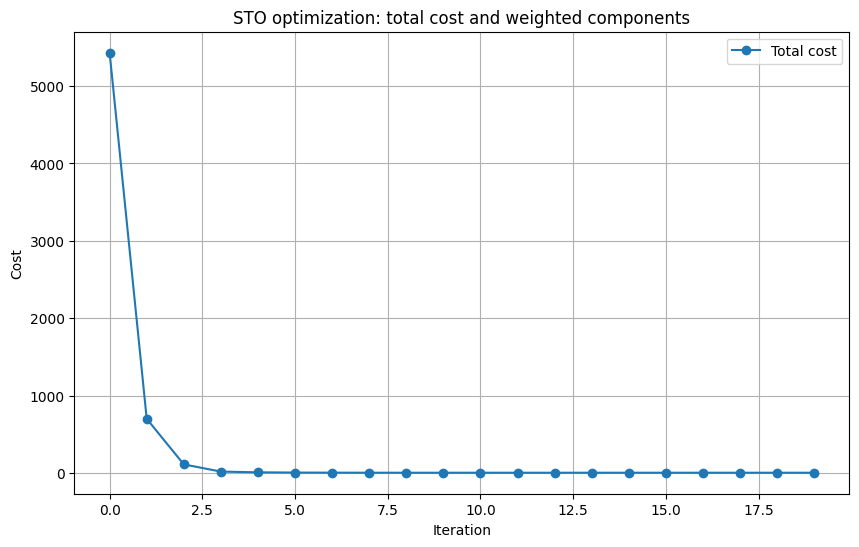


[9] OPTIMIZATION FINISHED
    Final loss: 2.094254
    Optimized total time (from tau): 64.0000 s


/tmp/ipykernel_9186/4161171506.py:259: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print(f"    Optimized total time (from tau): {float(T_opt):.4f} s")


In [32]:
"""
YOU CAN ADD NOISE TO INITIAL PARAMETERS (tau, xi) 
# Add small amount of noise to initial parameters
torch.manual_seed(42)  # For reproducibility (optional)

# Noise for tau (time parameters)
tau_noise_std = 0.5
tau_noise = tau_noise_std * torch.randn_like(tau_init)
tau = (tau_init + tau_noise).clone().detach().requires_grad_(True)

# Noise for xi (waypoint parameters)
xi_noise_std = 0.3  
xi_noise = xi_noise_std * torch.randn_like(xi_init)
xi = (xi_init + xi_noise).clone().detach().requires_grad_(True)

"""

###################################################
### (4) MINCO Model and Cost Function (Closure) ###
###################################################

from traj_gen_utils import MINCO_S3NU

# Construct headPVA and tailPVA tensors (initial, for info only)
headPVA = torch.cat([headPVA_pos, headPVA_vel, headPVA_acc], dim=0).unsqueeze(0)   # shape: (1, 3, 3)
tailPVA = torch.cat([tailPVA_pos, tailPVA_vel, tailPVA_acc], dim=0).unsqueeze(0)   # shape: (1, 3, 3)

# MINCO model
model = MINCO_S3NU(n_segments)

# Dynamic Limits
v_max = max_velocity        # [m/s] allowed max velocity
a_max = max_acceleration    # [m/s^2] allowed max acceleration

# Cost Weights
lambda_jerk = 10.0     # MINCO energy (jerk^2 integral) weight
lambda_vel  = 100.0    # velocity limit violation penalty weight
lambda_acc  = 5.0      # acceleration limit violation penalty weight
lambda_sfc  = 1000.0   # corridor (SFC) violation penalty weight

# Optimizer hyperparameters
learn_rate = 0.05
max_iter   = 20  # number of outer iterations

# IMPORTANT: We do NOT use max_iter inside LBFGS, only in the outer loop
optimizer = torch.optim.LBFGS(
    [tau, xi, headPVA_acc, tailPVA_acc],
    lr=learn_rate,
    line_search_fn="strong_wolfe"
)

# closure'ın son hesapladığı (weighted) cost terimlerini burada saklayacağız
last_cost_terms = {
    "total": 0.0,
    "jerk": 0.0,
    "vel": 0.0,
    "acc": 0.0,
    "sfc": 0.0,
}

def closure():
    optimizer.zero_grad()

    # 1) tau -> positive durations
    # tau: shape (1, n_segments-1, 1)
    t = tau_to_time_fixed_total(tau, T_fixed)   # shape: (1, n_segments, 1)


    # 2) xi -> internal waypoint positions (inside SFC)
    P_internal = forwardP_torch(
        xi=xi,
        v_idx=wp_corr_ids_minco,
        vPolys_torch=vPolys_torch,
        k_per_wp=k_per_wp
    )                          # shape: (n_wp, 3)
    points = P_internal.unsqueeze(0)   # shape: (1, n_wp, 3)  MINCO format

    # 3) Boundary conditions (head/tail PVA) – acc vectors are optimized parameters
    headPVA_cur = torch.cat(
        [headPVA_pos, headPVA_vel, headPVA_acc], dim=0
    ).unsqueeze(0)             # (1, 3, 3)

    tailPVA_cur = torch.cat(
        [tailPVA_pos, tailPVA_vel, tailPVA_acc], dim=0
    ).unsqueeze(0)             # (1, 3, 3)

    # 4) MINCO solve: jerk-minimized polynomial + energy
    energy = model(headPVA_cur, tailPVA_cur, points, t)   # scalar tensor
    traj = model.get_trajectory()[0]

    # 5) Sample trajectory (0 -> total duration)
    T_total = t.sum()          # scalar tensor
    s = torch.linspace(0.0, 1.0, steps=100, device=t.device)
    t_samples = s * T_total    # 100 samples in [0, T_total]

    pos = traj.pos(t_samples)  # (N, 3)
    vel = traj.vel(t_samples)  # (N, 3)
    acc = traj.acc(t_samples)  # (N, 3)

    vel_norm = vel.norm(dim=-1)   # (N,)
    acc_norm = acc.norm(dim=-1)   # (N,)

    # 6) Soft constraint penalty: velocity/acceleration limits
    vel_violation = torch.clamp(vel_norm - v_max, min=0.0)
    acc_violation = torch.clamp(acc_norm - a_max, min=0.0)

    cost_vel = (vel_violation ** 2).mean()
    cost_acc = (acc_violation ** 2).mean()

    # 6.b) SFC (safe corridor) penalty
    t_flat = t.view(-1)                    # (n_segments,)
    cum_t  = torch.cumsum(t_flat, dim=0)   # end time of each segment
    seg_idx = torch.bucketize(t_samples, cum_t)  # (N,)

    cost_sfc = torch.zeros(1, device=t.device)

    N_samp = min(pos.shape[0], seg_idx.shape[0])
    for s_idx in range(N_samp):
        seg = int(seg_idx[s_idx].item())       # 0..n_segments
        if seg >= n_segments:
            seg = n_segments - 1

        A_i = A_tensors[seg].to(t.device)
        b_i = b_tensors[seg].to(t.device).view(-1)

        x   = pos[s_idx]
        viola = A_i @ x - b_i
        viola_pos = torch.clamp(viola, min=0.0)

        cost_sfc = cost_sfc + (viola_pos ** 2).mean()

    cost_sfc = cost_sfc / N_samp

    # 7) Other cost terms (unweighted)
    cost_jerk = energy
    

    # 8) Weighted terms + total cost
    w_jerk = lambda_jerk * cost_jerk
    w_vel  = lambda_vel  * cost_vel
    w_acc  = lambda_acc  * cost_acc
    w_sfc  = lambda_sfc  * cost_sfc

    cost = w_jerk + w_vel + w_acc + w_sfc

    # 9) Gradients
    cost.backward()

    # --- DEBUG: cost components and grad norms (UNweighted print) ---
    with torch.no_grad():
        g_tau = None if tau.grad is None else tau.grad.norm().item()
        g_xi  = None if xi.grad is None else xi.grad.norm().item()
        g_hA  = None if headPVA_acc.grad is None else headPVA_acc.grad.norm().item()
        g_tA  = None if tailPVA_acc.grad is None else tailPVA_acc.grad.norm().item()

        """
        print("    [closure] cost components (unweighted):")
        print(f"        jerk  = {float(cost_jerk):.6f}")
        print(f"        vel   = {float(cost_vel):.6f}")
        print(f"        acc   = {float(cost_acc):.6f}")
        print(f"        sfc   = {float(cost_sfc):.6f}")
        print("    [closure] grad norms:")
        print(f"        ||∂cost/∂xi||         = {g_xi}")
        print(f"        ||∂cost/∂headPVA_acc||= {g_hA}")
        print(f"        ||∂cost/∂tailPVA_acc||= {g_tA}")
        """

        # Weighted cost terimlerini global dict'e kaydet
        last_cost_terms["total"] = float(cost.item())
        last_cost_terms["jerk"]  = float(w_jerk.item())
        last_cost_terms["vel"]   = float(w_vel.item())
        last_cost_terms["acc"]   = float(w_acc.item())
        last_cost_terms["sfc"]   = float(w_sfc.item())

    return cost

### Print Details
print("\n[7] OPTIMIZER AND COST FUNCTION DETAILS")
print(f"    Optimizer: LBFGS")
print(f"    Learning Rate: {learn_rate}")
print(f"    Max Outer Iterations: {max_iter}")
print(f"    Dynamic Limits: v_max = {v_max} m/s, a_max = {a_max} m/s^2")
print(f"    Cost Weights:")
print(f"        lambda_jerk = {lambda_jerk}")
print(f"        lambda_vel  = {lambda_vel}")
print(f"        lambda_acc  = {lambda_acc}")
print(f"        lambda_sfc  = {lambda_sfc}")


##########################################
### (5) Optimization Loop              ###
##########################################

loss_history      = []
jerk_history      = []
vel_history       = []
acc_history       = []
sfc_history       = []

print("\n[8] STARTING STO OPTIMIZATION")
print(f"    Max outer iterations: {max_iter}")

for it in range(max_iter):
    # Save parameters before step (for debug)
    with torch.no_grad():
        tau_before = tau.clone().detach()
        xi_before  = xi.clone().detach()

    # LBFGS: closure may be called several times inside
    loss = optimizer.step(closure)
    loss_val = loss.item()

    
    # cWrite cost terms to history
    loss_history.append(last_cost_terms["total"])
    jerk_history.append(last_cost_terms["jerk"])
    vel_history.append(last_cost_terms["vel"])
    acc_history.append(last_cost_terms["acc"])
    sfc_history.append(last_cost_terms["sfc"])
    
    # Measure parameter changes
    with torch.no_grad():
        dtau = (tau - tau_before).abs().max().item()
        dxi  = (xi  - xi_before ).abs().max().item()

    if it % 5 == 0 or it == max_iter - 1:
        

        # Print weighed cost components
        print("    [Iter {it:02d}] cost components (weighted):".format(it=it))
        print(f"        λ_jerk * jerk = {last_cost_terms['jerk']:.6f}")
        print(f"        λ_vel  * vel  = {last_cost_terms['vel']:.6f}")
        print(f"        λ_acc  * acc  = {last_cost_terms['acc']:.6f}")
        print(f"        λ_sfc  * sfc  = {last_cost_terms['sfc']:.6f}")  
        print(f"        Total loss = {loss_val:.6f}")

# =========== Plot: total + weighted components ===========

iters = range(len(loss_history))

plt.figure(figsize=(10, 6))
plt.plot(iters, loss_history, '-o', label='Total cost')
"""
plt.plot(iters, jerk_history, '-o', label='λ_jerk * jerk')
plt.plot(iters, vel_history, '-o', label='λ_vel * vel')
plt.plot(iters, acc_history, '-o', label='λ_acc * acc')
plt.plot(iters, sfc_history, '-o', label='λ_sfc * sfc')
"""
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("STO optimization: total cost and weighted components")
plt.legend()
plt.grid(True)
plt.show()

print("\n[9] OPTIMIZATION FINISHED")
print(f"    Final loss: {loss_history[-1]:.6f}")
T_opt = tau_to_time_fixed_total(tau, T_fixed).sum()
print(f"    Optimized total time (from tau): {float(T_opt):.4f} s")


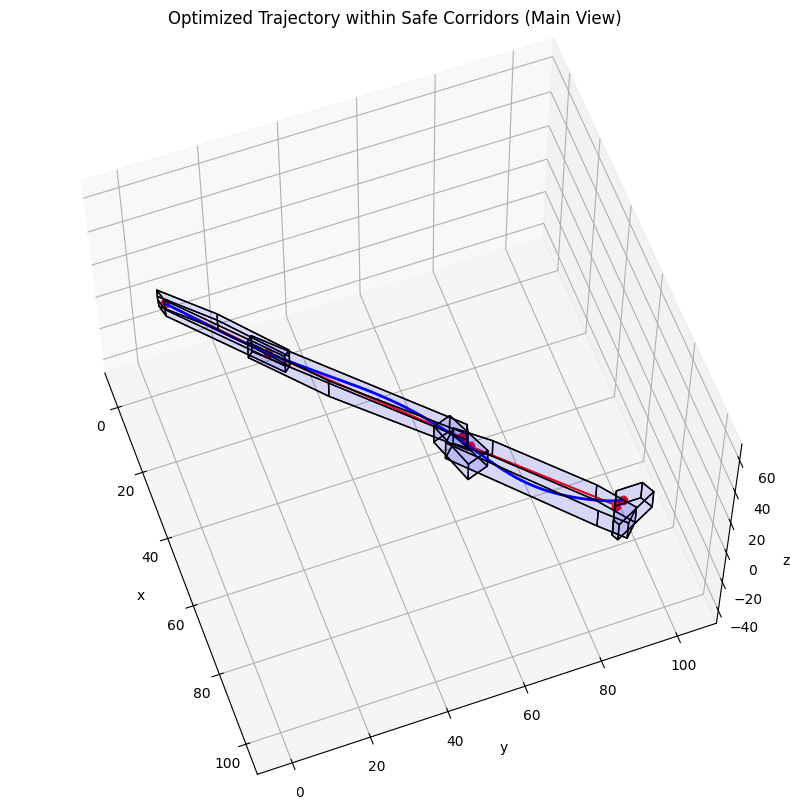

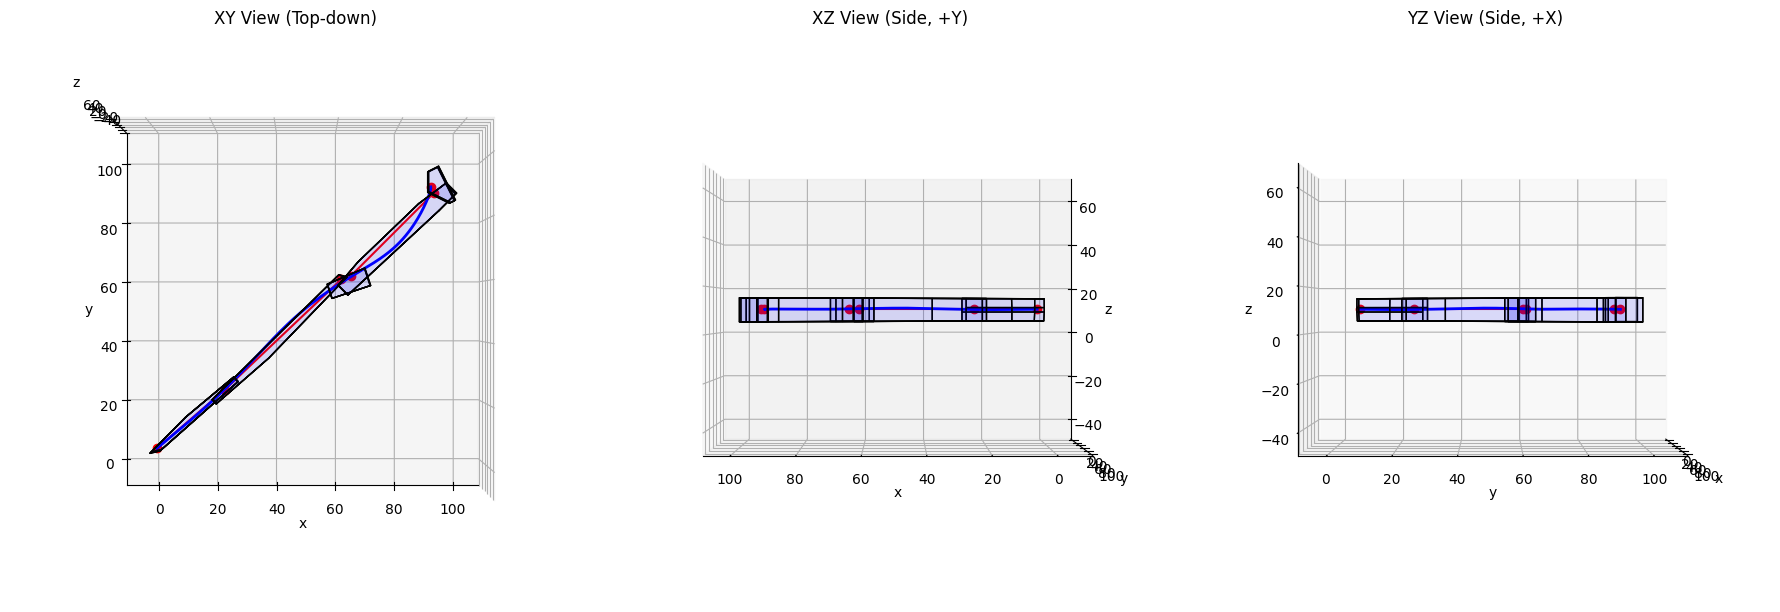

In [22]:
##########################################
### (7) Visualization / Sanity Checks  ###
##########################################

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import torch
import numpy as np
import pydecomp as pdc

# 1) Get the optimized trajectory
trajs = model.get_trajectory()
traj = trajs[0]

# 2) Sample positions along the trajectory
t_plot = torch.linspace(0.0, traj.ts[-1], steps=300)
p_final = traj.pos(t_plot).detach().cpu().numpy()   # [300, 3]

# ============================================================
# (5.1) Main view – same style as previous convex decomposition
# ============================================================

fig = plt.figure(figsize=(10, 10))
ax3d = fig.add_subplot(111, projection='3d')

# Safe flight corridors (convex decomposition)
pdc.visualize_environment(A_list, b_list, ax=ax3d)

# A* / pruned path
ax3d.plot3D(
    path_np[:, 0],
    path_np[:, 1],
    path_np[:, 2],
    c='r',
    marker='o'
)

# Optimized MINCO trajectory
ax3d.plot3D(
    p_final[:, 0],
    p_final[:, 1],
    p_final[:, 2],
    c='b',
    linewidth=2
)

ax3d.view_init(elev=60, azim=-20)  # main viewing angle
plt.title("Optimized Trajectory within Safe Corridors (Main View)")
plt.show()

# ============================================================
# (5.2) Three orthogonal views: XY, XZ, and YZ planes
# ============================================================

fig = plt.figure(figsize=(18, 6))

# Definitions:
# - XY plane: view along Z axis (top-down)        -> elev=90
# - XZ plane: view along +Y axis (side)           -> elev=0, azim=90
# - YZ plane: view along +X axis (side)           -> elev=0, azim=0

views = [
    (90,  -90, "XY View (Top-down)"),   # XY plane
    (0,    90, "XZ View (Side, +Y)"),   # XZ plane
    (0,     0, "YZ View (Side, +X)")    # YZ plane
]

for i, (elev, azim, title) in enumerate(views, start=1):
    ax = fig.add_subplot(1, 3, i, projection='3d')

    # Safe corridors
    pdc.visualize_environment(A_list, b_list, ax=ax)

    # A* / pruned path
    ax.plot3D(
        path_np[:, 0],
        path_np[:, 1],
        path_np[:, 2],
        c='r',
        marker='o'
    )

    # Optimized trajectory
    ax.plot3D(
        p_final[:, 0],
        p_final[:, 1],
        p_final[:, 2],
        c='b',
        linewidth=2
    )

    ax.view_init(elev=elev, azim=azim)
    ax.set_title(title)

plt.tight_layout()
plt.show()